# Preprocessing — tf_flowers
This notebook demonstrates and validates the preprocessing pipeline. It loads the raw dataset, applies resizing and normalization, splits into train/val/test sets, and verifies everything looks correct before training.

## 1. Imports

In [16]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# add src/ to path so we can import our own modules
sys.path.append(os.path.join("..", "src"))
from preprocess import load_data, split_data

# plot styling
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

## 2. Load and Preprocess Data
This calls `load_data()` from `src/preprocess.py` which downloads (or loads from cache), resizes to 128×128, and normalizes pixel values to 0–1.

In [17]:
images, labels, class_names, num_classes = load_data()

print(f"Images array shape : {images.shape}")
print(f"Labels array shape : {labels.shape}")
print(f"Class names        : {class_names}")
print(f"Number of classes  : {num_classes}")
print(f"Pixel value range  : [{images.min():.3f}, {images.max():.3f}]")
print(f"Data type          : {images.dtype}")

Images array shape : (3670, 128, 128, 3)
Labels array shape : (3670,)
Class names        : ['dandelion', 'daisy', 'tulips', 'sunflowers', 'roses']
Number of classes  : 5
Pixel value range  : [0.000, 1.000]
Data type          : float32


## 3. Verify Normalization
Pixel values should all be in the range [0, 1] after normalization. Confirm this holds across the full dataset.

In [18]:
assert images.min() >= 0.0, "Pixel values below 0 detected"
assert images.max() <= 1.0, "Pixel values above 1 detected"

print(f"Min pixel value : {images.min():.4f}  ✓")
print(f"Max pixel value : {images.max():.4f}  ✓")
print(f"Mean pixel value: {images.mean():.4f}")
print(f"Std pixel value : {images.std():.4f}")

Min pixel value : 0.0000  ✓
Max pixel value : 1.0000  ✓
Mean pixel value: 0.3956
Std pixel value : 0.2922


## 4. Verify Image Shape
Every image should be exactly 128×128×3 after resizing.

In [19]:
expected_shape = (128, 128, 3)
assert images.shape[1:] == expected_shape, f"Unexpected shape: {images.shape[1:]}"

print(f"Individual image shape: {images.shape[1:]}  ✓")
print(f"Total images          : {images.shape[0]}")

Individual image shape: (128, 128, 3)  ✓
Total images          : 3670


## 5. Train / Validation / Test Split
Split the data into 80% train, 10% validation, and 10% test. We use `stratify` to ensure each split has a balanced proportion of all 5 classes.

In [20]:
X_train, X_val, X_test, y_train, y_val, y_test = split_data(images, labels)

total = len(images)
print(f"Total images : {total}")
print(f"Train        : {len(X_train)} ({len(X_train)/total*100:.1f}%)")
print(f"Validation   : {len(X_val)}  ({len(X_val)/total*100:.1f}%)")
print(f"Test         : {len(X_test)}  ({len(X_test)/total*100:.1f}%)")

Total images : 3670
Train        : 2936 (80.0%)
Validation   : 367  (10.0%)
Test         : 367  (10.0%)


## 6. Verify Split Class Balance
Because we used `stratify=labels`, each split should have roughly the same proportion of each class. Verify this visually.

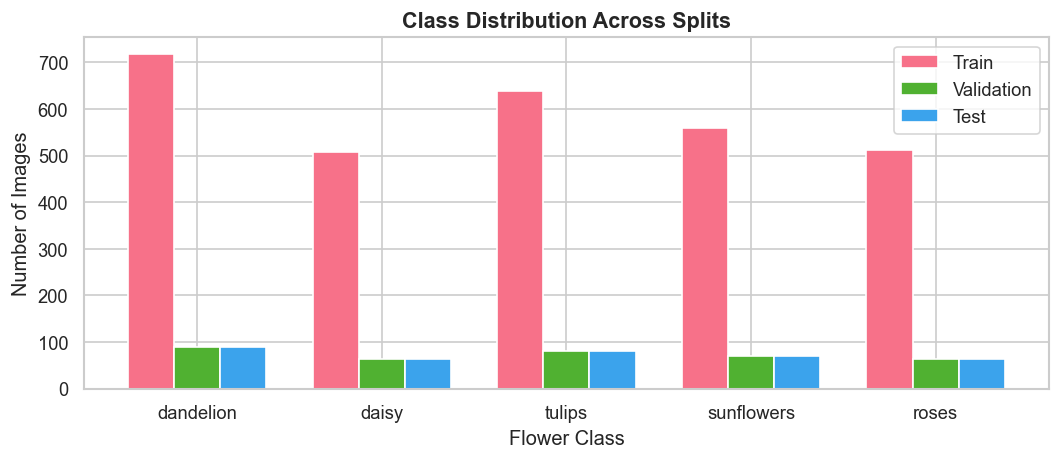

In [21]:
def class_counts(labels_array, class_names):
    counts = Counter(labels_array)
    return [counts[i] for i in range(len(class_names))]

train_counts = class_counts(y_train, class_names)
val_counts   = class_counts(y_val,   class_names)
test_counts  = class_counts(y_test,  class_names)

x = np.arange(num_classes)
width = 0.25
colors = sns.color_palette("husl", 3)

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x - width, train_counts, width, label="Train",      color=colors[0])
ax.bar(x,         val_counts,   width, label="Validation", color=colors[1])
ax.bar(x + width, test_counts,  width, label="Test",       color=colors[2])

ax.set_xticks(x)
ax.set_xticklabels(class_names)
ax.set_title("Class Distribution Across Splits", fontsize=13, fontweight="bold")
ax.set_xlabel("Flower Class")
ax.set_ylabel("Number of Images")
ax.legend()
plt.tight_layout()

plt.show()

## 7. Visualize Preprocessed Samples
Visually confirm the images look correct after resizing and normalization. We display pixel values back in 0–255 range for readability.

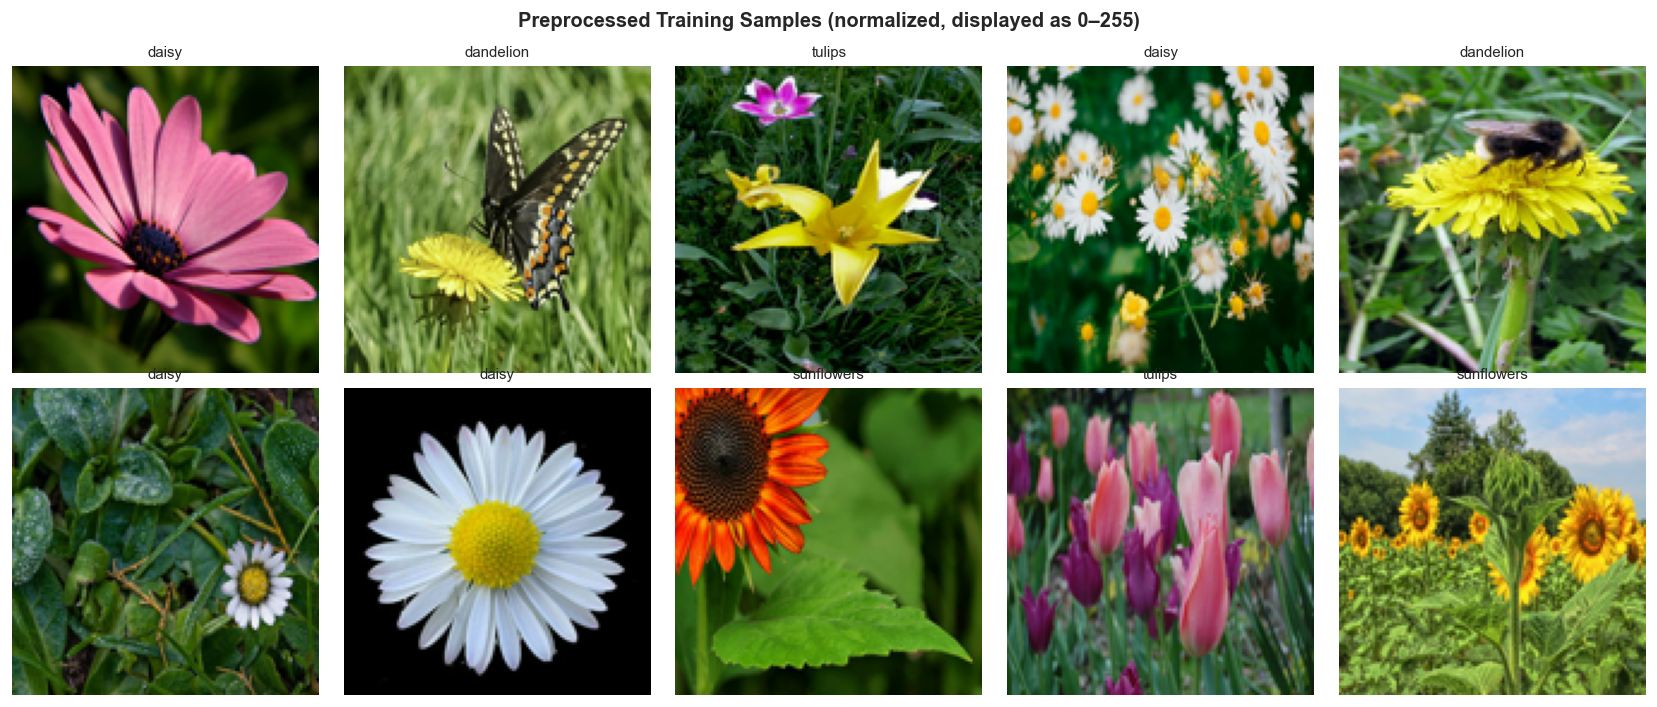

In [22]:
SAMPLES = 10
indices = np.random.choice(len(X_train), SAMPLES, replace=False)

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle("Preprocessed Training Samples (normalized, displayed as 0–255)", fontsize=12, fontweight="bold")

for ax, idx in zip(axes.flatten(), indices):
    img = (X_train[idx] * 255).astype("uint8")  # scale back for display only
    label = class_names[y_train[idx]]
    ax.imshow(img)
    ax.set_title(label, fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()

## 8. Visualize Augmentation
Preview what augmented versions of a single image look like. This helps validate that augmentation settings in `src/augment.py` produce realistic variations without distorting the images too much.

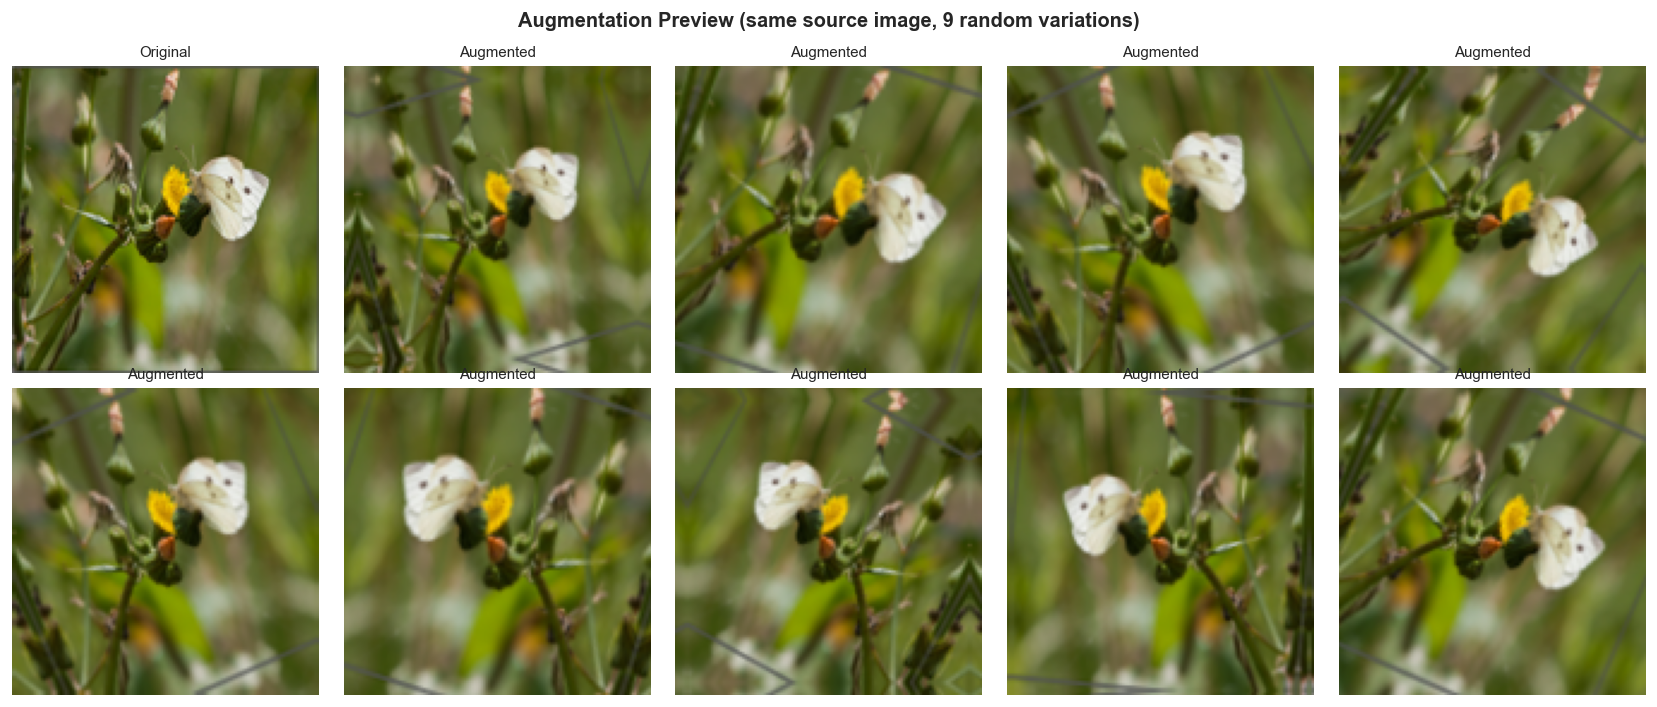

In [23]:
from augment import get_augmenter

augmenter = get_augmenter()

sample_img = X_train[2:3]  # shape (1, 128, 128, 3)

aug_images = [np.array(augmenter(sample_img, training=True)[0]) for _ in range(9)]

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle("Augmentation Preview (same source image, 9 random variations)", fontsize=12, fontweight="bold")

# original in first cell
axes.flatten()[0].imshow((sample_img[0] * 255).astype("uint8"))
axes.flatten()[0].set_title("Original", fontsize=9)
axes.flatten()[0].axis("off")

for ax, aug_img in zip(axes.flatten()[1:], aug_images):
    ax.imshow((np.clip(aug_img, 0, 1) * 255).astype("uint8"))
    ax.set_title("Augmented", fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()

## 9. Per-Channel Mean and Std
Compute the mean and standard deviation per color channel across the training set. Useful if you later switch from simple 0–1 normalization to z-score normalization (subtracting the mean and dividing by std).

In [24]:
channel_means = X_train.mean(axis=(0, 1, 2))
channel_stds  = X_train.std(axis=(0, 1, 2))

print("Per-channel statistics (training set, normalized 0–1):")
print(f"  Mean — R: {channel_means[0]:.4f}  G: {channel_means[1]:.4f}  B: {channel_means[2]:.4f}")
print(f"  Std  — R: {channel_stds[0]:.4f}  G: {channel_stds[1]:.4f}  B: {channel_stds[2]:.4f}")
print()
print("If switching to z-score normalization, use these values in preprocess.py:")
print(f"  mean = {list(np.round(channel_means, 4))}")
print(f"  std  = {list(np.round(channel_stds, 4))}")

Per-channel statistics (training set, normalized 0–1):
  Mean — R: 0.3488  G: 0.3488  B: 0.2708
  Std  — R: 0.2901  G: 0.2514  B: 0.2657

If switching to z-score normalization, use these values in preprocess.py:
  mean = [np.float32(0.3488), np.float32(0.3488), np.float32(0.2708)]
  std  = [np.float32(0.2901), np.float32(0.2514), np.float32(0.2657)]


## 10. Summary

In [25]:
print("=" * 45)
print("PREPROCESSING SUMMARY")
print("=" * 45)
print(f"Image size        : 128 x 128 x 3")
print(f"Normalization     : pixel / 255.0  (range 0–1)")
print(f"Total images      : {len(images)}")
print(f"Train set         : {len(X_train)}")
print(f"Validation set    : {len(X_val)}")
print(f"Test set          : {len(X_test)}")
print(f"Stratified split  : yes")
print(f"Classes           : {class_names}")
print("=" * 45)
print("Preprocessing pipeline validated — ready for training.")

PREPROCESSING SUMMARY
Image size        : 128 x 128 x 3
Normalization     : pixel / 255.0  (range 0–1)
Total images      : 3670
Train set         : 2936
Validation set    : 367
Test set          : 367
Stratified split  : yes
Classes           : ['dandelion', 'daisy', 'tulips', 'sunflowers', 'roses']
Preprocessing pipeline validated — ready for training.
